In [21]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


In [22]:
#import Overall Summary
overall_Summary = pd.read_csv(rf"C:\Projects\Battery Engineering\Summary Files\Overall Summary\B0053_Overall_Summary.csv")
overall_Summary.head()


        

,Cycle Pair,Battery ID,Charge_Ah,Discharge_Ah,Initial Discharge_Ah,Charge_Wh,Discharge_Wh,Charge Duration_Sec,Discharge Duration_Sec,Average_Charge_Voltage,...,Voltage Hysteresis,Max Charge Temperature,Max Discharge Temperature,Charge_Tempaerature_Rise_Rate,Discharge_Tempaerature_Rise_Rate,Coulombic_Efficiency_Ah,Energy_Efficiency_Wh,SOH,Capacity_Fade,Cycle Status
0,1,B0053,1.486472,1.419672,1.419672,6.219753,4.406133,10799.562,2528.109,4.197761,...,1.091779,8.673290,18.229675,0.000033,0.004929,95.506130,70.840965,102.876338,NaN,Valid
1,2,B0053,1.420802,1.398497,1.419672,5.921665,4.339326,10803.718,2489.781,4.192369,...,1.086369,17.665946,18.980521,-0.001075,0.005118,98.430091,73.278810,101.341893,1.534445,Valid
2,3,B0053,1.398386,1.379455,1.419672,5.828702,4.286949,10799.453,2455.969,4.192716,...,1.082361,18.210373,18.536944,-0.001154,0.005118,98.646177,73.548951,99.962007,1.379886,Valid
3,4,B0053,1.382724,1.371785,1.419672,5.764801,4.255127,10802.594,2442.078,4.193256,...,1.088571,17.938367,18.503456,-0.001124,0.005093,99.208842,73.812204,99.406232,0.555774,Valid
4,5,B0053,1.374320,1.371081,1.419672,5.730174,4.249302,10801.016,2440.968,4.193425,...,1.091371,17.867125,18.635706,-0.001127,0.004792,99.764296,74.156592,99.355205,0.051028,Valid


array([<Axes: xlabel='Cycle Pair'>, <Axes: xlabel='Cycle Pair'>],
      dtype=object)

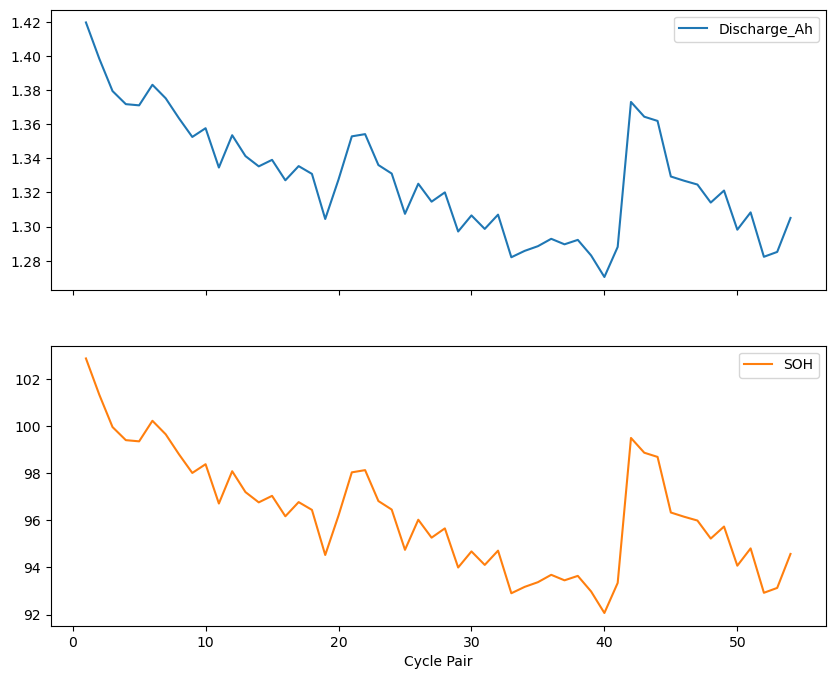

In [23]:
#Checking Battery Performance
overall_Summary.plot(x='Cycle Pair', y=['Discharge_Ah', 'SOH'], subplots=True, figsize=(10, 8))

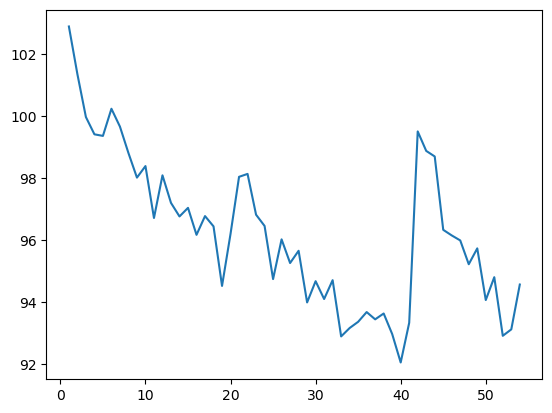

In [24]:
plt.plot(overall_Summary['Cycle Pair'], overall_Summary['SOH'])

Spike detected at index: 41


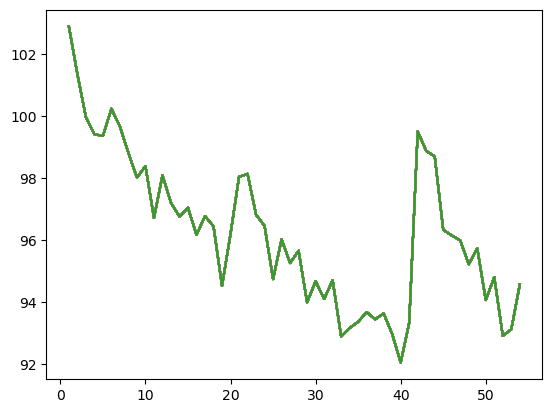

In [25]:


#Applying IQR filter to SOH data
Q1 = overall_Summary['SOH'].quantile(0.25)
Q3 = overall_Summary['SOH'].quantile(0.75)
IQR = Q3 - Q1
Lower_Limit = Q1 - 1.5 * IQR
Upper_Limit = Q3 + 1.5 * IQR

Cleaned_SOH = overall_Summary[(overall_Summary['SOH'] >= Lower_Limit) & (overall_Summary['SOH'] <= Upper_Limit)].copy()


#Splitting Data if Data is uneven
#Finding Index where Discharge AH is spiked 
spike_idx =0
Threshold = 0.05 # Identifying max spike greater than 5% change in Discharge_Ah between consecutive cycles. Adjust as needed.
for i in range(1,len(Cleaned_SOH)):
    if (Cleaned_SOH['Discharge_Ah'].iloc[i] - Cleaned_SOH['Discharge_Ah'].iloc[i-1]) / Cleaned_SOH['Discharge_Ah'].iloc[i-1] > Threshold: # Adjust the threshold as needed
        spike_idx = i
        Threshold = (Cleaned_SOH['Discharge_Ah'].iloc[i] - Cleaned_SOH['Discharge_Ah'].iloc[i-1]) / Cleaned_SOH['Discharge_Ah'].iloc[i-1]
        print(f"Spike detected at index: {spike_idx}")
        
    plt.plot(Cleaned_SOH['Cycle Pair'], Cleaned_SOH['SOH'])

In [26]:
# Applying Linear Regression Model
def apply_linear_regression(Cleaned_SOH):
    from sklearn.linear_model import LinearRegression
    from sklearn.metrics import mean_absolute_error, mean_squared_error

    X = Cleaned_SOH[['Cycle Pair']].values
    y = Cleaned_SOH['SOH'].values

    split_idx = int(0.8 * len(Cleaned_SOH))
    X_train, X_test = X[:split_idx], X[split_idx:]
    y_train, y_test = y[:split_idx], y[split_idx:]

    model = LinearRegression()
    model.fit(X_train, y_train)

    y_train_pred = model.predict(X_train)
    y_test_pred = model.predict(X_test)

    #Evaluating Error

    #1. Mean Absolute Error
    train_mae = mean_absolute_error(y_train, y_train_pred)
    test_mae = mean_absolute_error(y_test, y_test_pred)

    #2. Mean Squared Error
    train_mse = mean_squared_error(y_train, y_train_pred)
    test_mse = mean_squared_error(y_test, y_test_pred)

    print(f"Train MAE: {train_mae}, Test MAE: {test_mae}")
    print(f"Train MSE: {train_mse}, Test MSE: {test_mse}")

    # Plotting the regression line
    plt.figure(figsize=(10,6))
    plt.scatter(Cleaned_SOH['Cycle Pair'], Cleaned_SOH['SOH'], color='blue', label='Data Points')
    #plot traun and test predictions
    plt.plot(X_train, y_train_pred, color='red', label='Train Prediction')
    plt.plot(X_test, y_test_pred, color='green', label='Test Prediction')
    plt.xlabel('Cycle Pair')
    plt.ylabel('SOH')
    plt.title('Linear Regression Model for SOH Prediction')
    plt.legend()
    plt.show()

    slope = model.coef_[0]
    intercept = model.intercept_

    return {'slope': slope, 'intercept': intercept, 'train_mae': train_mae, 'test_mae': test_mae, 'train_mse': train_mse, 'test_mse': test_mse}



In [27]:
# Polynimal Regression Model
def apply_polynomial_regression(Cleaned_SOH):
    from sklearn.linear_model import LinearRegression
    from sklearn.metrics import mean_absolute_error, mean_squared_error
    from sklearn.preprocessing import PolynomialFeatures
    X = Cleaned_SOH[['Cycle Pair']].values
    y = Cleaned_SOH['SOH'].values

    #Splitting Data
    split_idx = int(0.8 * len(Cleaned_SOH))
    X_train, X_test = X[:split_idx], X[split_idx:]
    y_train, y_test = y[:split_idx], y[split_idx:]

    # Polynomial transformation
    poly = PolynomialFeatures(degree=2)
    X_train_poly = poly.fit_transform(X_train)
    X_test_poly = poly.transform(X_test)

    # Fit the model
    model = LinearRegression()
    model.fit(X_train_poly, y_train)

    # Predictions
    y_train_pred = model.predict(X_train_poly)
    y_test_pred = model.predict(X_test_poly)

    # Evaluating Error
    #1. Mean Absolute Error
    train_mae = mean_absolute_error(y_train, y_train_pred)
    test_mae = mean_absolute_error(y_test, y_test_pred)

    #2. Mean Squared Error
    train_mse = mean_squared_error(y_train, y_train_pred)
    test_mse = mean_squared_error(y_test, y_test_pred)

    print(f"Train MAE: {train_mae}, Test MAE: {test_mae}")
    print(f"Train MSE: {train_mse}, Test MSE: {test_mse}")

    # Plotting the regression line
    plt.figure(figsize=(10,6))
    plt.scatter(Cleaned_SOH['Cycle Pair'], Cleaned_SOH['SOH'], color='blue', label='Data Points')
    plt.plot(X_train, y_train_pred, color='red', label='Train Prediction')
    plt.plot(X_test, y_test_pred, color='green', label='Test Prediction')
    plt.xlabel('Cycle Pair')
    plt.ylabel('SOH')
    plt.title('Polynomial Regression Model for SOH Prediction')
    plt.legend()
    plt.show()

    return {'coefficients': model.coef_, 'intercept': model.intercept_, 'train_mae': train_mae, 'test_mae': test_mae, 'train_mse': train_mse, 'test_mse': test_mse}

Data is not monotonically Declining
Train MAE: 0.7784807882563953, Test MAE: 0.5515617454096081
Train MSE: 0.9826567211575783, Test MSE: 0.3986802542395042


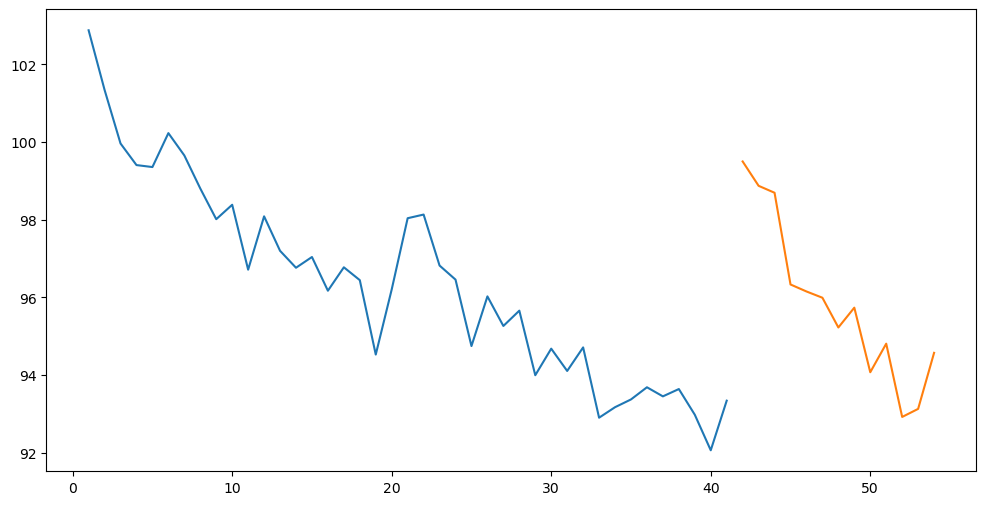

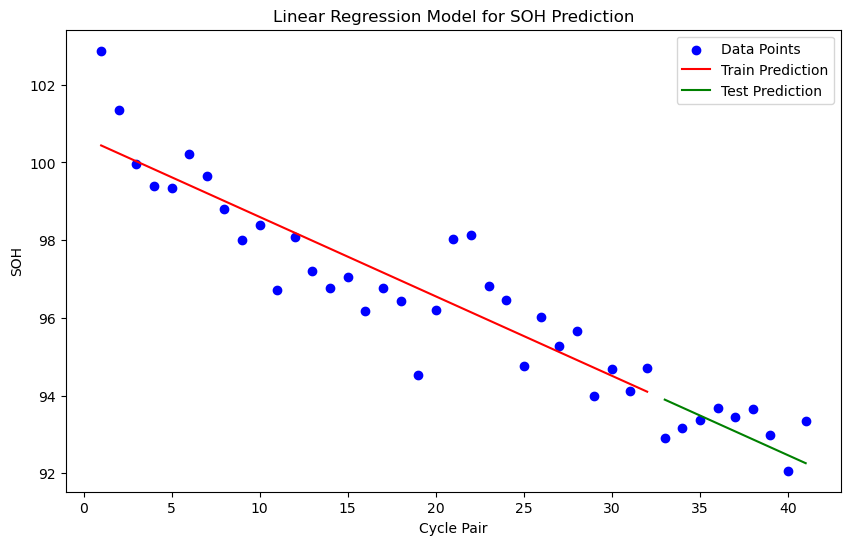

Train MAE: 0.5843273902939317, Test MAE: 1.0293176512940694
Train MSE: 0.3964672118226814, Test MSE: 1.8860472109768678


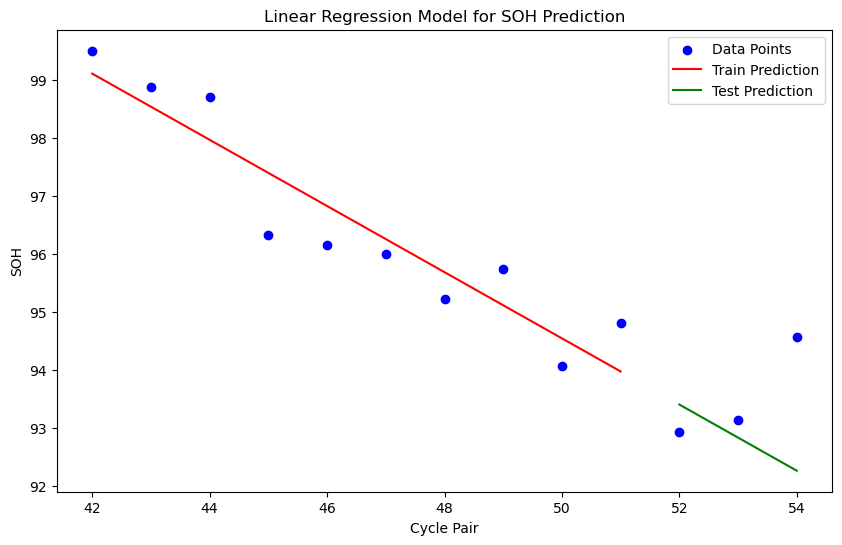

Train MAE: 0.6872105227139067, Test MAE: 1.7318942499108863
Train MSE: 0.8154596866072465, Test MSE: 3.242211629751646


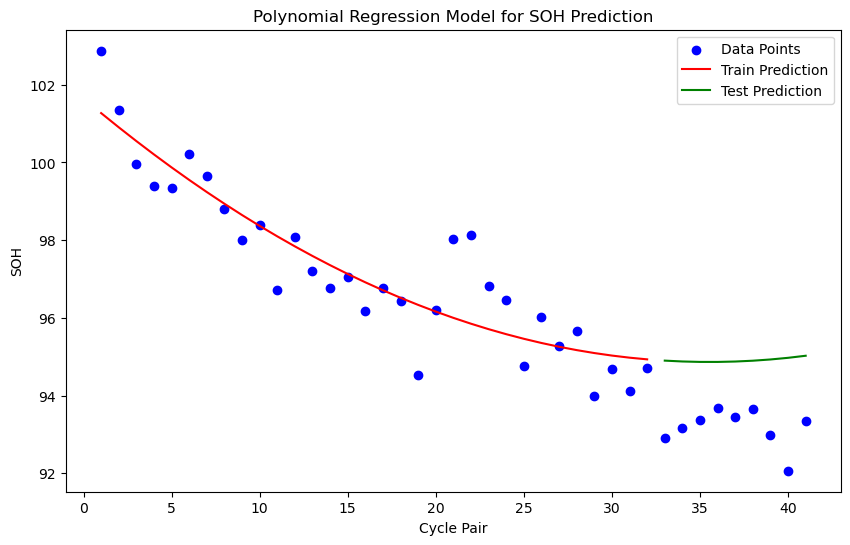

Linear Regression is better


In [ ]:
if spike_idx != 0:
    print("Data is not monotonically Declining")
    #Splitting Data into two parts
    part1 = Cleaned_SOH.iloc[:spike_idx]
    part2 = Cleaned_SOH.iloc[spike_idx:]

    #Plotting both parts
    plt.figure(figsize=(12, 6))
    plt.plot(part1['Cycle Pair'], part1['SOH'], label='Part 1')
    plt.plot(part2['Cycle Pair'], part2['SOH'], label='Part 2')

    #Applying linear regression to both parts
    Linear_Op = apply_linear_regression(part1)
    apply_linear_regression(part2)
    Poly_Op= apply_polynomial_regression(part1)

    #Comparing Linear and Polynomial Regression
    if Linear_Op['test_mae'] > Poly_Op['test_mae']:
        print("Preferred Model : Polynomial Regression")
        chosen_model = "Polynomial Regression"
    else:
        print("Preferred Model : Linear Regression")
        chosen_model = "Linear Regression"

else:
    print("Data is monotonically Declining")
    Linear_Op = apply_linear_regression(Cleaned_SOH)
    Poly_Op = apply_polynomial_regression(Cleaned_SOH)

    if Linear_Op['test_mae'] > Poly_Op['test_mae']:
        print("Preferred Model : Polynomial Regression")
        chosen_model = "Polynomial Regression"
        
    else:
        print("Preferred Model : Linear Regression")
        chosen_model = "Linear Regression"

Train MAE: 0.6872105227139067, Test MAE: 1.7318942499108863
Train MSE: 0.8154596866072465, Test MSE: 3.242211629751646


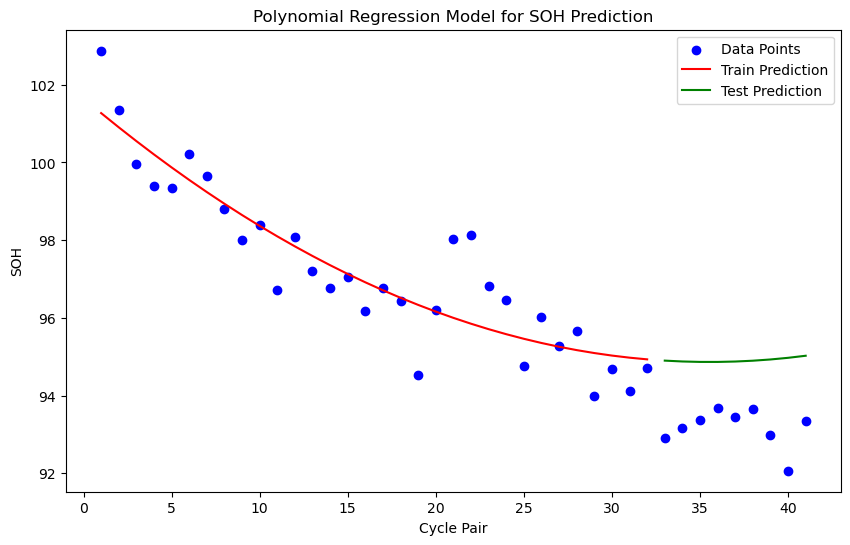

Train MAE: 0.41027082549757665, Test MAE: 1.1370099888749035
Train MSE: 0.24667750859678406, Test MSE: 1.6930192200342027


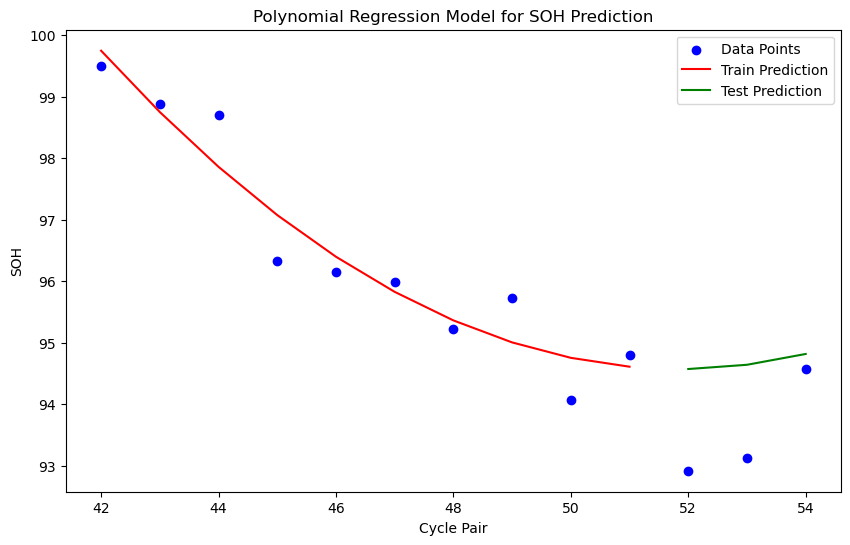

{'coefficients': array([ 0.        , -5.52364517,  0.0532628 ]),
 'intercept': np.float64(237.78102981060817),
 'train_mae': 0.41027082549757665,
 'test_mae': 1.1370099888749035,
 'train_mse': 0.24667750859678406,
 'test_mse': 1.6930192200342027}

In [29]:
apply_polynomial_regression(part1)
apply_polynomial_regression(part2)
